
Enter START configuration:


  Start Joint 1 angle (degrees):  15
  Start Joint 2 angle (degrees):  30



Enter END configuration:


  End Joint 1 angle (degrees):  40
  End Joint 2 angle (degrees):  60



Optimizing trajectory...
Start: Joint1=15.0°, Joint2=30.0°
End:   Joint1=40.0°, Joint2=60.0°

✓ Optimization successful!


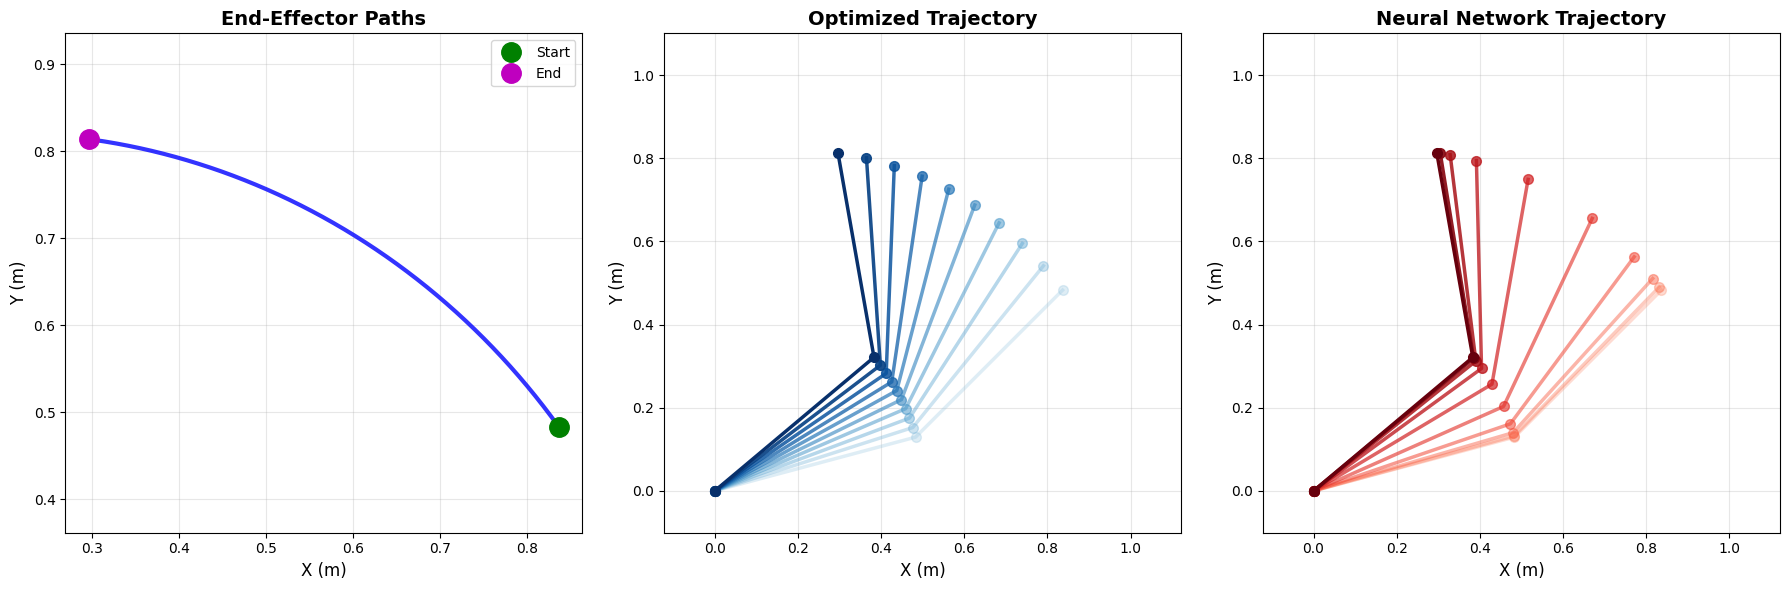

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')


def coordinate(q1, q2, l1=0.5, l2=0.5):
    x1 = l1 * np.cos(np.radians(q1))
    y1 = l1 * np.sin(np.radians(q1))
    x2 = x1 + l2 * np.cos(np.radians(q1 + q2))
    y2 = y1 + l2 * np.sin(np.radians(q1 + q2))
    return x2, y2

def optimize_trajectory(q_start, q_end, N=500, T=5.0):
    dt = T / (N-1)
    
    def objective(x):
        q = x.reshape((N, 2))
        v = (q[1:] - q[:-1]) / dt
        return np.sum(v**2)
    
    def start_constraint(x):
        q = x.reshape((N, 2))
        return q[0] - q_start
    
    def end_constraint(x):
        q = x.reshape((N, 2))
        return q[-1] - q_end
    
    cons = [
        {'type': 'eq', 'fun': start_constraint},
        {'type': 'eq', 'fun': end_constraint}
    ]
    
    initial_guess = np.linspace(q_start, q_end, N).flatten()
    res = minimize(objective, initial_guess, constraints=cons, method='SLSQP', options={'disp': False})
    
    q_opt = res.x.reshape((N, 2))
    return q_opt, res.success

def neural_network_prediction(q_start, q_end, N=500):
    t = np.linspace(0, 1, N)

    smooth_t = 1 / (1 + np.exp(-10*(t - 0.5)))
    smooth_t = (smooth_t - smooth_t[0]) / (smooth_t[-1] - smooth_t[0])
    
    q_nn = np.zeros((N, 2))
    for i in range(2):
        q_nn[:, i] = q_start[i] + (q_end[i] - q_start[i]) * smooth_t
    
    return q_nn

def plot_comparison(q_start, q_end):
    """Create comparison plots"""
    N = 500
    T = 5.0
    
    print(f"\n{'='*60}")
    print(f"Optimizing trajectory...")
    print(f"Start: Joint1={q_start[0]}°, Joint2={q_start[1]}°")
    print(f"End:   Joint1={q_end[0]}°, Joint2={q_end[1]}°")
    print(f"{'='*60}\n")
    
    q_opt, success = optimize_trajectory(q_start, q_end, N, T)
    
    if success:
        print("✓ Optimization successful!")
    else:
        print("✗ Optimization failed!")
    
  
    q_nn = neural_network_prediction(q_start, q_end, N)   
    ee_x_opt, ee_y_opt = coordinate(q_opt[:, 0], q_opt[:, 1])
    ee_x_nn, ee_y_nn = coordinate(q_nn[:, 0], q_nn[:, 1])
       
    fig = plt.figure(figsize=(18, 6))
    ax1 = plt.subplot(1, 3, 1)
    ax1.plot(ee_x_opt, ee_y_opt, 'b-', linewidth=3,alpha=0.8)
    ax1.plot(ee_x_opt[0], ee_y_opt[0], 'go', markersize=14, label='Start', zorder=5)
    ax1.plot(ee_x_opt[-1], ee_y_opt[-1], 'mo', markersize=14, label='End', zorder=5)
    ax1.set_xlabel('X (m)', fontsize=12)
    ax1.set_ylabel('Y (m)', fontsize=12)
    ax1.set_title('End-Effector Paths', fontsize=14, fontweight='bold')
    ax1.axis('equal')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    
    ax2 = plt.subplot(1, 3, 2)
    snapshot_indices = np.linspace(0, N-1, 10, dtype=int)
    for idx in snapshot_indices:
        q1, q2 = q_opt[idx, 0], q_opt[idx, 1]
        x1 = 0.5 * np.cos(np.radians(q1))
        y1 = 0.5 * np.sin(np.radians(q1))
        x2, y2 = coordinate(q1, q2)
        
        alpha = 0.3 + 0.7 * (idx / (N-1))
        ax2.plot([0, x1, x2], [0, y1, y2], 'o-', 
                 color=plt.cm.Blues(0.4 + 0.6*idx/(N-1)), 
                 alpha=alpha, linewidth=2.5, markersize=7)
    
    ax2.set_xlabel('X (m)', fontsize=12)
    ax2.set_ylabel('Y (m)', fontsize=12)
    ax2.set_title('Optimized Trajectory', fontsize=14, fontweight='bold')
    ax2.axis('equal')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(-0.2, 1.2)
    ax2.set_ylim(-0.2, 1.2)
    
    
    ax3 = plt.subplot(1, 3, 3)
    for idx in snapshot_indices:
        q1, q2 = q_nn[idx, 0], q_nn[idx, 1]
        x1 = 0.5 * np.cos(np.radians(q1))
        y1 = 0.5 * np.sin(np.radians(q1))
        x2, y2 = coordinate(q1, q2)
        
        alpha = 0.3 + 0.7 * (idx / (N-1))
        ax3.plot([0, x1, x2], [0, y1, y2], 'o-', 
                 color=plt.cm.Reds(0.4 + 0.6*idx/(N-1)), 
                 alpha=alpha, linewidth=2.5, markersize=7)
    
    ax3.set_xlabel('X (m)', fontsize=12)
    ax3.set_ylabel('Y (m)', fontsize=12)
    ax3.set_title('Neural Network Trajectory', fontsize=14, fontweight='bold')
    ax3.axis('equal')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(-0.2, 1.2)
    ax3.set_ylim(-0.2, 1.2)
    
    plt.tight_layout()
    plt.show()

print("=" * 60)
print("=" * 60)


print("\nEnter START configuration:")
start_j1 = float(input("  Start Joint 1 angle (degrees): "))
start_j2 = float(input("  Start Joint 2 angle (degrees): "))

print("\nEnter END configuration:")
end_j1 = float(input("  End Joint 1 angle (degrees): "))
end_j2 = float(input("  End Joint 2 angle (degrees): "))


q_start = np.array([start_j1, start_j2])
q_end = np.array([end_j1, end_j2])


plot_comparison(q_start, q_end)